# Module 4 Lab 1: Describe and Correlate

**Repo URL:** <https://github.com/roee0910/cs82a-portfolio.git>

**Data:** my own `sales_clean.csv` from Lab 3.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Load your clean data

In [2]:
df = pd.read_csv("sales_clean.csv")
print(df.shape)
df.head()

(292, 6)


,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


## Step 2: Center and spread of price and qty

In [3]:
df[["price", "qty"]].agg(["mean", "median", "std"]).round(2)

,price,qty
mean,55.52,2.99
median,37.53,3.00
std,71.77,1.41


## Step 3: Which summary would I report for price?

I would report the median for price. The mean is 55.52 but the median is only 37.53, which tells me that a few expensive items are pulling the average up. The median is closer to what a typical sale looks like.

## Step 4: Histogram of price

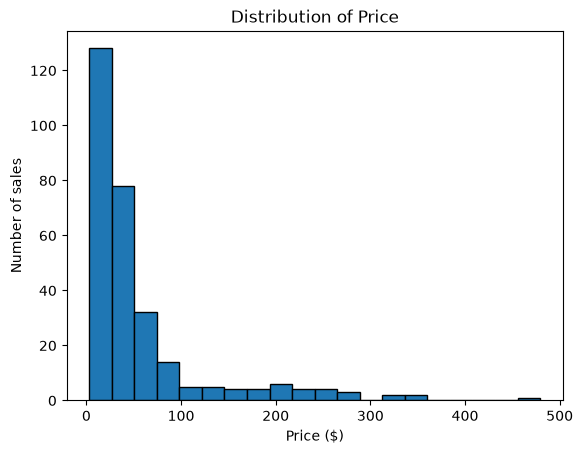

In [4]:
df["price"].plot(kind="hist", bins=20, edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price ($)")
plt.ylabel("Number of sales")
plt.show()

**Shape:** The histogram is right-skewed. Most sales are at low prices (the tallest bar is at the far left), and there is a long tail of expensive items going up to about $480. This matches my choice of the median in Step 3.

## Step 5: Create the revenue column

In [5]:
df["revenue"] = df["price"] * df["qty"]
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


## Step 6: Correlation matrix

In [6]:
df.corr(numeric_only=True).round(3)

,order_id,price,qty,zip,revenue
order_id,1.000,-0.005,0.031,-0.015,0.004
price,-0.005,1.000,-0.042,0.024,0.821
qty,0.031,-0.042,1.000,0.087,0.313
zip,-0.015,0.024,0.087,1.000,0.047
revenue,0.004,0.821,0.313,0.047,1.000


The strongest off-diagonal value is price vs. revenue (r = 0.82), but that one is partly built in, since revenue is price × qty. The pair I care about is qty vs. revenue, with r = 0.31, a weak to moderate positive relationship. Price and qty are almost unrelated (r = -0.04).

## Step 7: Scatter plot to verify

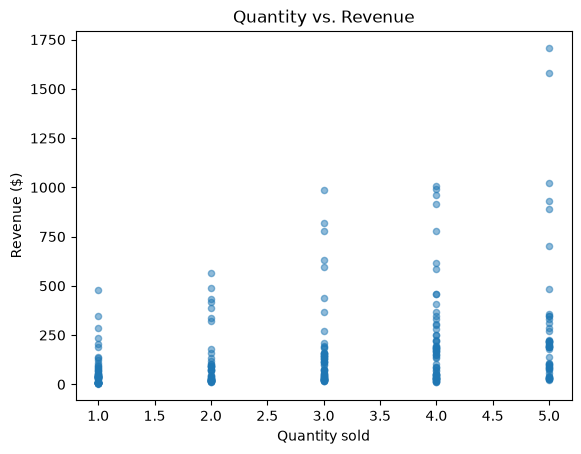

In [7]:
df.plot.scatter(x="qty", y="revenue", alpha=0.5)
plt.title("Quantity vs. Revenue")
plt.xlabel("Quantity sold")
plt.ylabel("Revenue ($)")
plt.show()

The scatter shows a mild upward drift, which agrees with r = 0.31. Because qty only takes the values 1 to 5, the points sit in vertical columns, and the spread gets wider as qty goes up.

## Step 8: The analyst's sentence

Orders with a higher quantity tend to bring in more revenue, but the link is only weak to moderate (r = 0.31), so quantity by itself explains only about 10% of the differences in revenue. Be careful, because price matters more, a few expensive items like monitors create the very large orders, and this correlation does not prove that getting customers to buy more units would raise revenue.

## Step 9: By-hand check

List: [2, 4, 4, 6, 9]

**Mean by hand:** 2 + 4 + 4 + 6 + 9 = 25, and 25 / 5 numbers = **5.0**

**Median by hand:** the list is already sorted and has 5 numbers, so the median is the middle (3rd) one, which is **4**.

Now I verify both with Python:

In [8]:
data = pd.Series([2, 4, 4, 6, 9])
print("mean:", data.mean())
print("median:", data.median())

mean: 5.0
median: 4.0
